In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Circle

In [2]:
import pandas as pd
df = pd.read_csv(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\CadenceGraphs\VTC_VD_ID.csv")
x_axis = df["X"]*1000
VCBL = df["Vin"]
ID = df["ID"]
ID_Diff = np.diff(ID)
ID_Diff = np.append(ID_Diff,ID_Diff[-1])

C:\Users\91880\AppData\Local\Temp\ipykernel_35832\1380252744.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [10]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

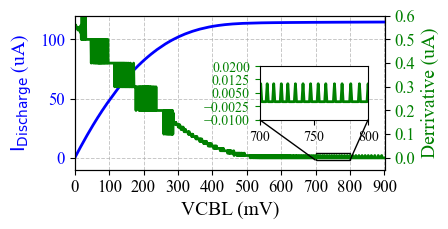

In [11]:
fig, ax1 = plt.subplots(1, 1, figsize=(4, 2),sharex=True)
ax2 = ax1.twinx()
#ax1.plot(x_axis,VCBL, color="g",linewidth=2, alpha = 1, label = "VCBL")
ax1.plot(x_axis,ID*10**6, color="b",linewidth=2, alpha = 1, label = "IDischarge")
ax2.plot(x_axis,ID_Diff*10**6, color="g",linewidth=2, alpha = 1, label = "VCBL")
ax1.tick_params(axis='y', labelcolor = "b")
ax2.tick_params(axis='y', labelcolor = "g")

ax1.set_ylabel(r"$\text{I}_\text{Discharge}$ (uA)", color="b")

ax2.set_ylabel("Derrivative (uA)", color="g")
ax1.set_xlabel("VCBL (mV)")
ax1.set_xlim(0,901)
ax2.set_ylim(-0.05,0.6)
ax1.set_ylim(-10,120)
ax1.set_xticks(np.arange(0, 901, 100))
ax2.set_yticks(np.arange(0, 0.61, 0.1))

#fig.suptitle(r"VCBL vs $\text{I}_\text{Discharge}$ characteristic")
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)


# ---------------- Zoomed inset (ax2) ----------------
x1, x2 = 700, 800
y1, y2 = -0.01, 0.02

axins = inset_axes(
    ax2,
    width="35%",
    height="35%",
    loc="center right",
    borderpad=1
)

axins.plot(x_axis, ID_Diff * 1e6, color="g", linewidth=2)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Zoomed ticks
axins.set_xticks([700, 750, 800])
axins.set_yticks(np.linspace(-0.01, 0.02, 5))

axins.tick_params(axis='y', colors='g', labelsize=10)
axins.tick_params(axis='x', labelsize=10)

# Match inset spines to ax2 color
for spine in axins.spines.values():
    spine.set_color('black')

# Draw rectangle + connectors
mark_inset(ax2, axins, loc1=3, loc2=4, fc="none", ec="black")

# ---------------- Optional: circular zoom ----------------
#circle = Circle((0.5, 0.5), 0.5, transform=axins.transAxes)
#axins.set_clip_path(circle)

#axins.add_patch(Circle((0.5, 0.5), 0.5,transform=axins.transAxes, fill=False, linewidth=2))

plt.savefig(r"D:\ISSCC_26\Graphs\VTC_VD_ID.jpg", dpi=800, bbox_inches="tight")
